# Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


#Load Data

In [3]:
df = pd.read_csv('/content/drive/MyDrive/GEE_exports/nc_coast_final.csv',
                 parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
print(df.shape)
df.head()

(1373, 8)


,buoy_id,timestamp,wave_height,SST,temperature_2m,total_precipitation,u_wind,v_wind
0,41110,2020-01-01,0.751875,15.752083,282.956753,2.145767e-06,3.656345,-0.302013
1,41110,2020-01-02,0.453958,15.231250,283.567308,8.761882e-07,1.425865,1.161455
2,41110,2020-01-03,0.799362,14.840426,290.960683,3.710985e-05,2.777287,4.178292
3,41110,2020-01-04,1.183958,15.335417,292.144864,4.783556e-03,4.275726,3.913683
4,41110,2020-01-05,0.888750,15.462500,282.884910,2.384269e-04,5.230590,-2.394793


In [4]:
df.describe()

,buoy_id,timestamp,wave_height,SST,temperature_2m,total_precipitation,u_wind,v_wind
count,1373.0,1373,1373.000000,1373.000000,1373.000000,1.373000e+03,1373.000000,1373.000000
mean,41110.0,2021-12-12 14:38:53.576110592,0.922973,20.740761,291.783034,3.565239e-03,0.608754,0.189105
min,41110.0,2020-01-01 00:00:00,0.329167,9.881250,270.491762,-2.384240e-08,-6.374090,-8.594423
25%,41110.0,2020-12-09 00:00:00,0.690208,15.658333,286.592577,2.568095e-06,-0.979458,-1.763335
50%,41110.0,2021-11-27 00:00:00,0.853958,21.095833,292.738239,2.993301e-04,0.789250,0.356866
75%,41110.0,2022-12-10 00:00:00,1.062708,26.506250,297.904820,3.596473e-03,2.152712,2.153831
max,41110.0,2023-12-30 00:00:00,3.210417,30.106250,302.646959,6.990248e-02,6.837851,8.468824
std,0.0,NaN,0.339221,5.782505,6.930176,7.554818e-03,2.077042,2.589659


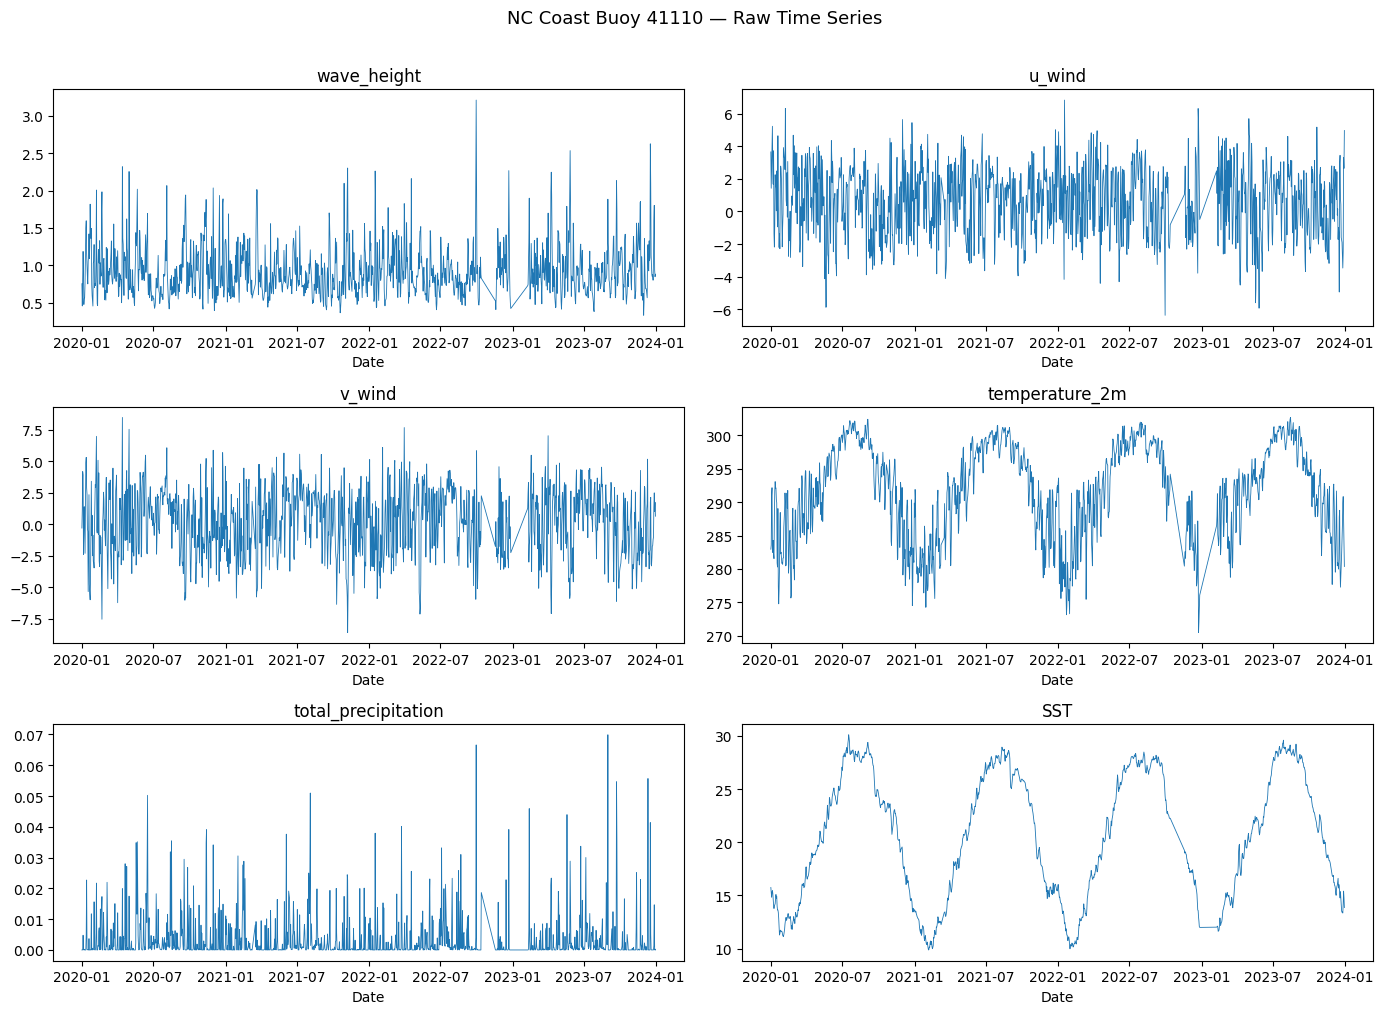

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
features = ['wave_height', 'u_wind', 'v_wind', 'temperature_2m', 'total_precipitation', 'SST']
for ax, col in zip(axes.flat, features):
    ax.plot(df['timestamp'], df[col], lw=0.6)
    ax.set_title(col)
    ax.set_xlabel('Date')
plt.suptitle('NC Coast Buoy 41110 — Raw Time Series', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [6]:
feature_cols = ['u_wind', 'v_wind', 'temperature_2m', 'total_precipitation']
target_col = 'wave_height'
window = 60

#drop rows with NaN in any relevant column
df_clean = df[feature_cols + [target_col]].dropna()
print(f"Clean rows: {len(df_clean)}")

# Normalize
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(df_clean[feature_cols].values)
y_scaled = scaler_y.fit_transform(df_clean[[target_col]].values).ravel()

# build sliding windows
def make_windows(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_win, y_win = make_windows(X_scaled, y_scaled, window)
print(f"Windowed X: {X_win.shape}  y: {y_win.shape}")
X_win = X_win.transpose(0, 2, 1)
print(f"After transpose for CNN: {X_win.shape}")

Clean rows: 1373
Windowed X: (1313, 60, 4)  y: (1313,)
After transpose for CNN: (1313, 4, 60)


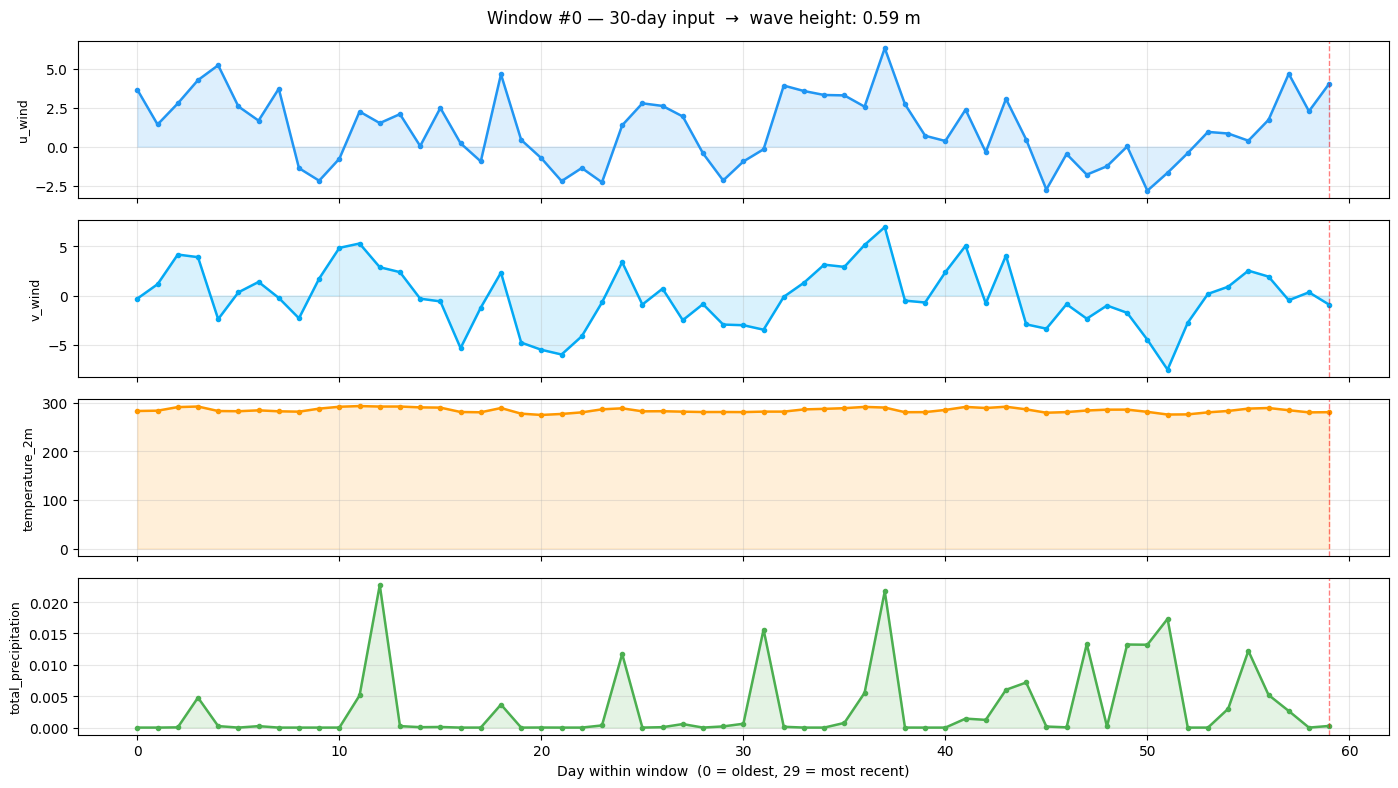

In [8]:
sample_idx = 0
window_data = X_win[0]
target_val  = scaler_y.inverse_transform([[y_win[sample_idx]]])[0][0]

colors = ['#2196F3', '#03A9F4', '#FF9800', '#4CAF50']
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

for i, (ax, feat, color) in enumerate(zip(axes, feature_cols, colors)):
    dummy = np.zeros((window, len(feature_cols)))
    dummy[:, i] = window_data[i]
    orig = scaler_X.inverse_transform(dummy)[:, i]
    ax.plot(range(window), orig, color=color, lw=1.8, marker='o', markersize=3)
    ax.fill_between(range(window), orig, alpha=0.15, color=color)
    ax.set_ylabel(feat, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axvline(window - 1, color='red', lw=1, ls='--', alpha=0.5)

axes[-1].set_xlabel('Day within window  (0 = oldest, 29 = most recent)')
fig.suptitle(f'Window #{sample_idx} — 30-day input  →  wave height: {target_val:.2f} m', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
n = len(X_win)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

X_train, y_train = X_win[:train_end], y_win[:train_end]
X_val,   y_val   = X_win[train_end:val_end], y_win[train_end:val_end]
X_test,  y_test  = X_win[val_end:], y_win[val_end:]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (919, 4, 60) | Val: (197, 4, 60) | Test: (197, 4, 60)


In [10]:
class WaveDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

batch = 80
train_loader = DataLoader(WaveDataset(X_train, y_train), batch_size=batch, shuffle=True)
val_loader   = DataLoader(WaveDataset(X_val,   y_val),   batch_size=batch)
test_loader  = DataLoader(WaveDataset(X_test,  y_test),  batch_size=batch)

In [11]:
class WaveCNN(nn.Module):
    def __init__(self, n_features=4, window=30, dropout=0.3):
        super().__init__()
        self.conv_block = nn.Sequential(
            # Block 1 — capture short-range patterns (3-day)
            nn.Conv1d(n_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Block 2 — medium-range patterns (7-day)
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Block 3 — longer-range patterns (14-day)
            nn.Conv1d(128, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.global_pool(x)
        return self.fc(x).squeeze(-1)

model = WaveCNN(n_features=len(feature_cols), window=window).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

WaveCNN(
  (conv_block): Sequential(
    (0): Conv1d(4, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Conv1d(128, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 101,953


In [12]:
epochs = 40
lr     = 1e-2

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

history = {'train_loss': [], 'val_loss': []}
best_val = float('inf')
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_losses.append(criterion(model(xb), yb).item())

    tl = np.mean(train_losses)
    vl = np.mean(val_losses)
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    scheduler.step(vl)

    if vl < best_val:
        best_val = vl
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{epochs}  train_loss={tl:.4f}  val_loss={vl:.4f}")

print(f"\nBest val loss: {best_val:.4f}")

Epoch  10/40  train_loss=0.8115  val_loss=1.6555
Epoch  20/40  train_loss=0.7971  val_loss=1.8124
Epoch  30/40  train_loss=0.7840  val_loss=1.6226
Epoch  40/40  train_loss=0.7762  val_loss=1.6395

Best val loss: 1.6000


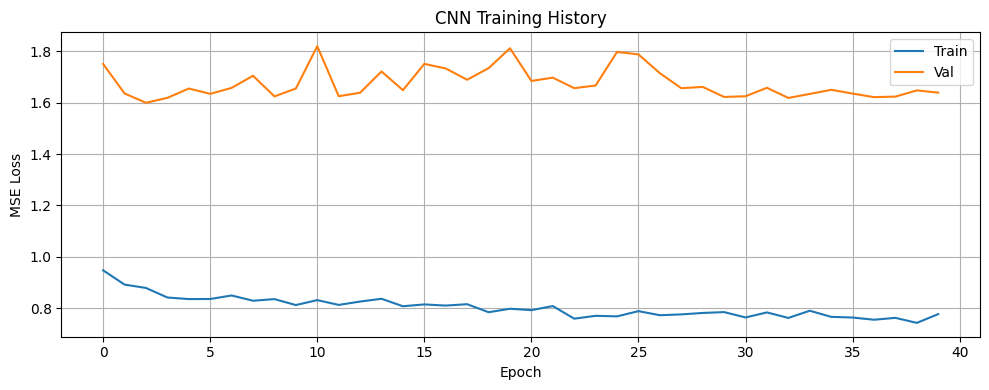

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'],   label='Val')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('CNN Training History'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

In [14]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds.extend(model(xb.to(device)).cpu().numpy())
        trues.extend(yb.numpy())

preds_m = scaler_y.inverse_transform(np.array(preds).reshape(-1, 1)).ravel()
trues_m = scaler_y.inverse_transform(np.array(trues).reshape(-1, 1)).ravel()

rmse = np.sqrt(mean_squared_error(trues_m, preds_m))
mae  = mean_absolute_error(trues_m, preds_m)
r2   = r2_score(trues_m, preds_m)

print(f"Test RMSE : {rmse:.4f} m")
print(f"Test MAE  : {mae:.4f} m")
print(f"Test R^2   : {r2:.4f}")

Test RMSE : 0.3363 m
Test MAE  : 0.2436 m
Test R^2   : -0.0089


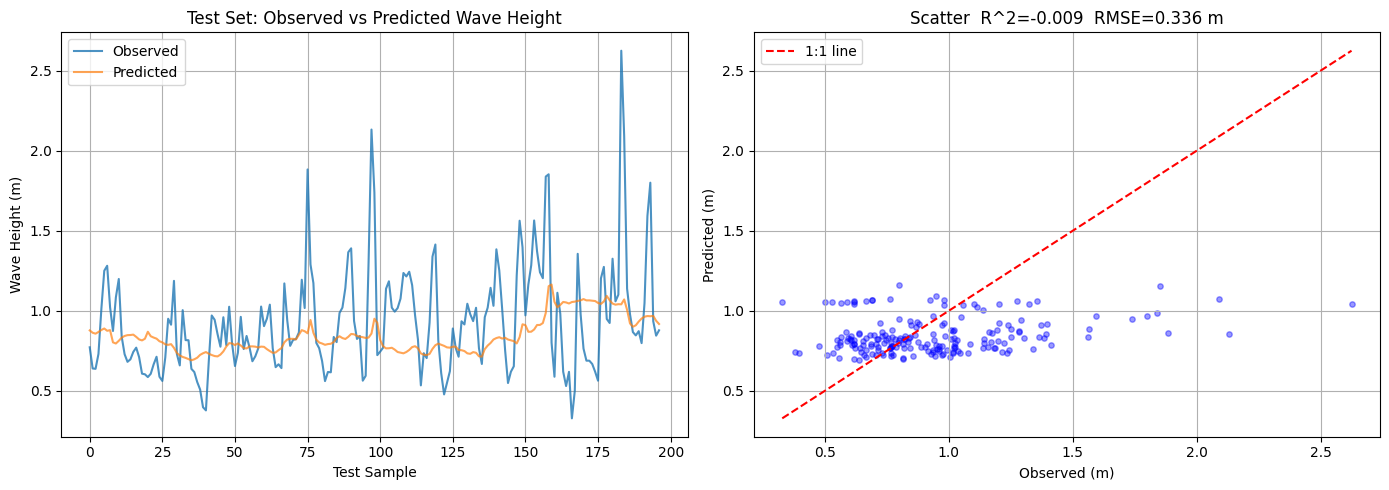

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series comparison
axes[0].plot(trues_m, label='Observed', alpha=0.8)
axes[0].plot(preds_m, label='Predicted', alpha=0.7)
axes[0].set_title('Test Set: Observed vs Predicted Wave Height')
axes[0].set_xlabel('Test Sample'); axes[0].set_ylabel('Wave Height (m)')
axes[0].legend(); axes[0].grid(True)

# Scatter
axes[1].scatter(trues_m, preds_m, alpha=0.4, s=15, c='blue')
mn, mx = trues_m.min(), trues_m.max()
axes[1].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='1:1 line')
axes[1].set_xlabel('Observed (m)'); axes[1].set_ylabel('Predicted (m)')
axes[1].set_title(f'Scatter  R^2={r2:.3f}  RMSE={rmse:.3f} m')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

In [16]:
# import os
# os.makedirs('/content/drive/MyDrive/nc_coast_models', exist_ok=True)
# torch.save({'model_state': model.state_dict(),
#             'scaler_X': scaler_X, 'scaler_y': scaler_y,
#             'window': window, 'features': feature_cols},
#            '/content/drive/MyDrive/nc_coast_models/model1_cnn_wave.pt')
# print("Model saved.")

# LSTM Version

In [17]:
class WaveLSTM(nn.Module):
    def __init__(self, input_size, hidden=64, layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model = WaveLSTM(input_size=len(feature_cols)).to(device)
print(model)

WaveLSTM(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [18]:
for lag in [1, 2, 3]:
    df[f'wave_height_lag{lag}'] = df['wave_height'].shift(lag)

feature_cols = ['u_wind', 'v_wind', 'temperature_2m', 'total_precipitation',
                'wave_height_lag1', 'wave_height_lag2', 'wave_height_lag3']
target_col   = 'wave_height'
window       = 60
epochs       = 100
lr           = 1e-3
batch        = 62

df_clean = df[feature_cols + [target_col]].dropna().reset_index(drop=True)
print(f"Clean rows: {len(df_clean)}")

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(df_clean[feature_cols].values)
y_scaled = scaler_y.fit_transform(df_clean[[target_col]].values).ravel()

X_win, y_win = make_windows(X_scaled, y_scaled, window)
print(X_win.shape)

n = len(X_win)
train_end, val_end = int(0.70*n), int(0.85*n)
X_train, y_train = X_win[:train_end],        y_win[:train_end]
X_val,   y_val   = X_win[train_end:val_end], y_win[train_end:val_end]
X_test,  y_test  = X_win[val_end:],          y_win[val_end:]
print(X_train.shape)

train_loader = DataLoader(WaveDataset(X_train, y_train), batch_size=batch, shuffle=True)
val_loader   = DataLoader(WaveDataset(X_val,   y_val),   batch_size=batch)
test_loader  = DataLoader(WaveDataset(X_test,  y_test),  batch_size=batch)


del model
model = WaveLSTM(input_size=len(feature_cols)).to(device)

Clean rows: 1370
(1310, 60, 7)
(916, 60, 7)


In [19]:
X_win, y_win = make_windows(X_scaled, y_scaled, window)
print(f"X_win: {X_win.shape}  y_win: {y_win.shape}")

X_win: (1310, 60, 7)  y_win: (1310,)


In [20]:
n = len(X_win)
train_end, val_end = int(0.70*n), int(0.85*n)
X_train, y_train = X_win[:train_end],        y_win[:train_end]
X_val,   y_val   = X_win[train_end:val_end], y_win[train_end:val_end]
X_test,  y_test  = X_win[val_end:],          y_win[val_end:]

In [21]:
model = WaveLSTM(input_size=len(feature_cols)).to(device)
print(model)

WaveLSTM(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [22]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

history = {'train': [], 'val': []}
best_val, best_state = float('inf'), None
patience_counter = 0
EARLY_STOP = 25

for epoch in range(1, epochs+1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            val_losses.append(criterion(model(xb.to(device)), yb.to(device)).item())

    tl, vl = np.mean(train_losses), np.mean(val_losses)
    history['train'].append(tl)
    history['val'].append(vl)
    scheduler.step(vl)

    if vl < best_val:
        best_val = vl
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{epochs}  train_loss={tl:.4f}  val_loss={vl:.4f}")

model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.4f}")

Epoch  10/100  train_loss=0.6895  val_loss=0.9826
Epoch  20/100  train_loss=0.5990  val_loss=0.8905
Epoch  30/100  train_loss=0.5730  val_loss=0.8634
Epoch  40/100  train_loss=0.5494  val_loss=0.8757
Epoch  50/100  train_loss=0.5013  val_loss=0.9082
Epoch  60/100  train_loss=0.5000  val_loss=0.9245
Early stopping at epoch 61
Best val loss: 0.8457


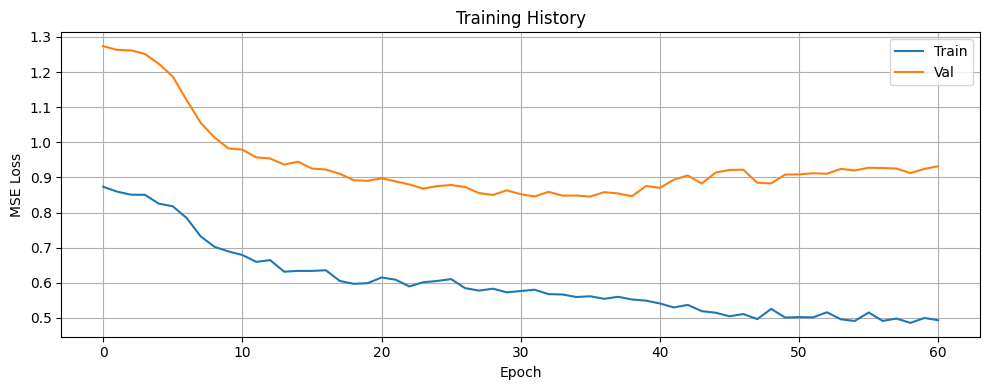

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(history['train'], label='Train')
plt.plot(history['val'],   label='Val')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training History'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

In [24]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds.extend(model(xb.to(device)).cpu().numpy())
        trues.extend(yb.numpy())

preds_m = scaler_y.inverse_transform(np.array(preds).reshape(-1,1)).ravel()
trues_m = scaler_y.inverse_transform(np.array(trues).reshape(-1,1)).ravel()

rmse = np.sqrt(mean_squared_error(trues_m, preds_m))
mae  = mean_absolute_error(trues_m, preds_m)
r2   = r2_score(trues_m, preds_m)
print(f"Test RMSE : {rmse:.4f} m")
print(f"Test MAE  : {mae:.4f} m")
print(f"Test R^2   : {r2:.4f}")

Test RMSE : 0.2811 m
Test MAE  : 0.1997 m
Test R^2   : 0.2950


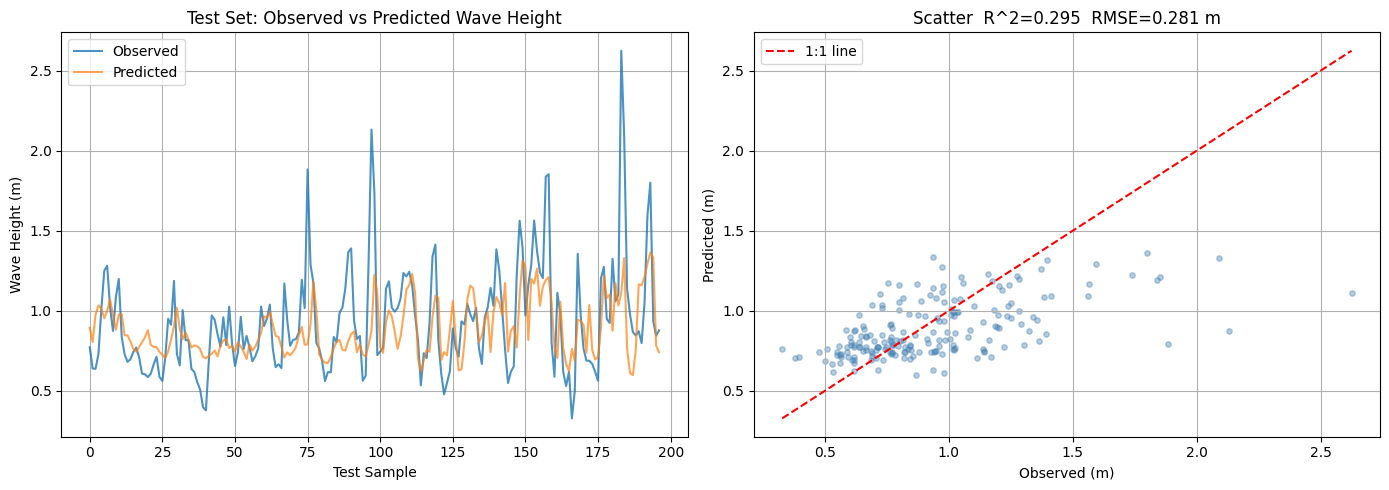

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(trues_m, label='Observed', alpha=0.8)
axes[0].plot(preds_m, label='Predicted', alpha=0.7)
axes[0].set_title('Test Set: Observed vs Predicted Wave Height')
axes[0].set_xlabel('Test Sample'); axes[0].set_ylabel('Wave Height (m)')
axes[0].legend(); axes[0].grid(True)

axes[1].scatter(trues_m, preds_m, alpha=0.4, s=15, c='steelblue')
mn, mx = trues_m.min(), trues_m.max()
axes[1].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='1:1 line')
axes[1].set_xlabel('Observed (m)'); axes[1].set_ylabel('Predicted (m)')
axes[1].set_title(f'Scatter  R^2={r2:.3f}  RMSE={rmse:.3f} m')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()